In [1]:
import sys
import jax

import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../")
from lib_jax.mmd_gaussian_dc import cosh_gaussian_kernel, sinh_gaussian_kernel, positive_gaussian_kernel, negative_gaussian_kernel

In [8]:
def plot_fig(positive_part, negative_part, bandwidth, ax=None, xmin=-3, xmax=3, ymin=0, ymax=1.75,
             xp="signed", legend=True):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(6, 4))

    xs = np.linspace(xmin, xmax, 1000)
    pos_kernel = jax.vmap(lambda t: positive_part(t, 0, bandwidth))(xs[:,None])
    neg_kernel = jax.vmap(lambda t: negative_part(t, 0, bandwidth))(xs[:,None])
    diff_part = pos_kernel - neg_kernel

    gaussian_kernel = np.exp(-xs**2/ (2*bandwidth))

    ax.plot(xs, pos_kernel, label=r"$q_+(t^2)$")
    ax.plot(xs, neg_kernel, label=r"$q_-(t^2)$")
    ax.plot(xs, gaussian_kernel, label=r"$q(t^2)=e^{-t^2}$")    
    ax.plot(xs, diff_part, "--", label=r"$q(t^2)_+ - q_-(t^2)$")

    ax.set_xlabel(r"$t$")
    # ax.set_ylabel("Function values")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.grid()
    if legend:
        ax.legend(fontsize=13, loc="lower right", ncols=1)

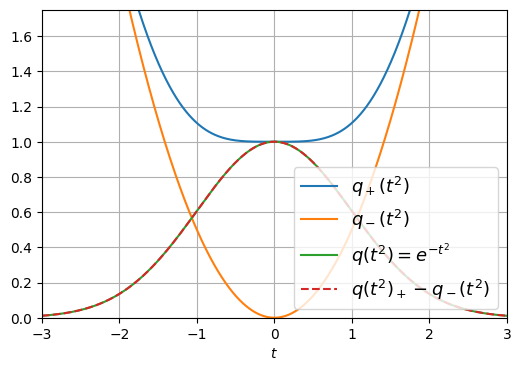

In [9]:
bandwidth = 1
plot_fig(positive_gaussian_kernel, negative_gaussian_kernel, bandwidth)
plt.savefig("./Figures/decomposition_q_signed.pdf", format="pdf", bbox_inches="tight")

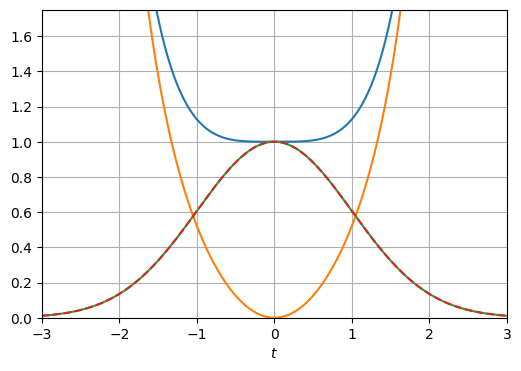

In [10]:
bandwidth = 1
plot_fig(cosh_gaussian_kernel, sinh_gaussian_kernel, bandwidth, xp="cosh", legend=False)
plt.savefig("./Figures/decomposition_q_cosh.pdf", format="pdf", bbox_inches="tight")